# Modelagem comparativa — Base 01: Bitcoin

**Modelo de especialização do grupo:** Support Vector Regression (SVR)  
**Base analisada:** Base 01 — Bitcoin  
**Objetivo:** prever o preço de fechamento do próximo candle diário (`t+1`) com SARIMAX, Holt-Winters, Random Forest e SVR.

O notebook aplica a mesma data de origem, horizonte de um dia e conjunto de teste aos quatro modelos. A seleção de hiperparâmetros ocorre somente no pré-teste; o teste final permanece fora da amostra. As variáveis OHLCV do candle `t` só entram depois de seu fechamento, quando já estão disponíveis.

In [18]:
# Bibliotecas
import os
import warnings
from itertools import product
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)

BASE_ID = 'base_01'
RESPONSAVEL = 'Grupo do SVR (base atribuída: 01)'
TARGET = 'priceClose'
FREQ = 'D'
HORIZON = 1
TEST_SIZE = 365                 # último ano: teste final comum e intocado pelo tuning
VALIDATION_SIZE = 60            # validação interna dos modelos clássicos
MODEL_SEASONAL_PERIOD = 7
STL_PERIODS = {
    'Semanal': 7, 'Quinzenal': 15, 'Mensal': 30, 'Bimestral': 60,
    'Trimestral': 90, 'Semestral': 182, 'Anual': 365,
}
RANDOM_STATE = 42
LJUNG_BOX_LAG = 10
ML_REFIT_EVERY = 1              # walk-forward expansivo estrito
PERMUTATION_REPEATS = 10

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / 'data/raw' / BASE_ID / 'bitcoin.xlsx'
PROCESSED_PATH = ROOT / 'data/processed' / f'{BASE_ID}.parquet'
PREDICTIONS_PATH = ROOT / 'results/predictions' / f'{BASE_ID}_predictions.csv'
METRICS_PATH = ROOT / 'results/metrics' / f'{BASE_ID}_metrics.csv'
SARIMAX_TUNING_PATH = ROOT / 'results/metrics' / f'{BASE_ID}_sarimax_tuning.csv'
SARIMAX_COEFFICIENTS_PATH = ROOT / 'results/metrics' / f'{BASE_ID}_sarimax_coefficients.csv'
HW_TUNING_PATH = ROOT / 'results/metrics' / f'{BASE_ID}_holt_winters_tuning.csv'
HW_PARAMETERS_PATH = ROOT / 'results/metrics' / f'{BASE_ID}_holt_winters_parameters.csv'
RESIDUALS_PATH = ROOT / 'results/residuals' / f'{BASE_ID}_residuals.csv'
IMPORTANCE_PATH = ROOT / 'results/feature_importance' / f'{BASE_ID}_feature_importance.csv'
FIGURES_DIR = ROOT / 'results/figures' / BASE_ID

for directory in {
    PROCESSED_PATH.parent, PREDICTIONS_PATH.parent, METRICS_PATH.parent,
    RESIDUALS_PATH.parent, IMPORTANCE_PATH.parent, FIGURES_DIR,
}:
    directory.mkdir(parents=True, exist_ok=True)

print('Arquivo de entrada:', DATA_PATH)

Arquivo de entrada: C:\Users\pietromedico-ieg\OneDrive - Instituto Germinare\Área de Trabalho\Tech\SeriesTemporais\PraticaFinal\modelos-svr\data\raw\base_01\bitcoin.xlsx


## 1. Identificação da base e disponibilidade das variáveis

- **Fonte imediata:** `bitcoin.xlsx`, arquivo fornecido para a Base 01. O provedor original não consta na planilha; por isso não é atribuído sem evidência.
- **Cobertura observada:** 22/08/2018 a 12/09/2026 (UTC), confirmada abaixo após a leitura.
- **Frequência:** diária.
- **Alvo:** `priceClose`, cotado em unidade monetária por Bitcoin (a moeda de cotação não está documentada no arquivo).
- **Horizonte:** fechamento do próximo candle diário.
- **Origem da previsão:** instante de fechamento do candle atual. Assim, OHLC e volume do candle atual já são conhecidos.

### Dicionário das covariáveis

| Variável | Significado | Unidade | Disponibilidade na origem | Uso |
|---|---|---|---|---|
| `priceOpen` | preço de abertura do candle | moeda/BTC | após o fechamento de `t` | transformação defasada para `t+1` |
| `priceHigh` | maior preço do candle | moeda/BTC | após o fechamento de `t` | amplitude defasada |
| `priceLow` | menor preço do candle | moeda/BTC | após o fechamento de `t` | amplitude defasada |
| `volume` | volume negociado informado | unidade não documentada | após o fechamento de `t` | log-volume e variação defasados |
| calendário | dia da semana de `t+1` | sem unidade | conhecido antecipadamente | encoding cíclico |

Os termos “defasada” e “de origem” são essenciais: nenhuma observação de OHLCV do candle previsto é utilizada.

## 2. Carregamento e auditoria temporal

São verificados esquema, nulos, duplicatas, ordem original, duração dos candles e regularidade entre fechamentos. `timeClose` é usado como relógio do experimento porque é quando todas as covariáveis do candle se tornam conhecidas.

In [19]:
raw = pd.read_excel(DATA_PATH, sheet_name=0)

required_columns = {
    'timeOpen', 'timeClose', 'timeHigh', 'timeLow',
    'priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume',
}
missing_columns = required_columns - set(raw.columns)
if missing_columns:
    raise ValueError(f'Colunas ausentes: {sorted(missing_columns)}')

timestamp_columns = ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']
for column in timestamp_columns:
    raw[f'{column}_dt'] = pd.to_datetime(raw[column], unit='ms', utc=True)

if raw.timeOpen_dt.is_monotonic_increasing:
    original_order = 'crescente'
elif raw.timeOpen_dt.is_monotonic_decreasing:
    original_order = 'decrescente'
else:
    original_order = 'irregular'

ordered_closes = raw.timeClose_dt.sort_values()
close_gaps = ordered_closes.diff().dropna()
audit = pd.DataFrame({
    'observacoes': [len(raw)],
    'inicio_candle': [raw.timeOpen_dt.min()],
    'fim_candle': [raw.timeClose_dt.max()],
    'duplicatas_timeClose': [raw.timeClose.duplicated().sum()],
    'nulos_totais': [raw[list(required_columns)].isna().sum().sum()],
    'ordem_original': [original_order],
    'lacunas_maiores_que_1_dia': [(close_gaps > pd.Timedelta(days=1)).sum()],
})
display(audit, raw.head(3))

,observacoes,inicio_candle,fim_candle,duplicatas_timeClose,nulos_totais,ordem_original,lacunas_maiores_que_1_dia
0,2920,2018-08-22 12:00:00+00:00,2026-09-12 11:59:59.999000+00:00,0,0,decrescente,5


,timeOpen,timeClose,timeHigh,timeLow,priceOpen,priceHigh,priceLow,priceClose,volume,timeOpen_dt,timeClose_dt,timeHigh_dt,timeLow_dt
0,1789128000000,1789214399999,1789178640000,1789173060000,76559.124754,79818.337264,76162.917834,77173.793101,3.741100e+10,2026-09-11 12:00:00+00:00,2026-09-12 11:59:59.999000+00:00,2026-09-12 02:04:00+00:00,2026-09-12 00:31:00+00:00
1,1789041600000,1789127999999,1789063140000,1789125360000,78260.386707,78520.968768,76470.640041,76568.124134,3.012011e+10,2026-09-10 12:00:00+00:00,2026-09-11 11:59:59.999000+00:00,2026-09-10 17:59:00+00:00,2026-09-11 11:16:00+00:00
2,1788955200000,1789041599999,1788986220000,1789035000000,78440.597811,79737.300200,77768.148072,78259.519666,2.919241e+10,2026-09-09 12:00:00+00:00,2026-09-10 11:59:59.999000+00:00,2026-09-09 20:37:00+00:00,2026-09-10 10:10:00+00:00


## 3. Limpeza e regularização diária

Os registros são ordenados, duplicatas são removidas e uma grade diária é criada. Nos dias ausentes, preços recebem somente o último valor conhecido (`ffill`) e o volume recebe zero; `imputado` preserva a informação de que o candle foi criado. Não há interpolação que consulte o futuro.

In [20]:
price_columns = ['priceOpen', 'priceHigh', 'priceLow', 'priceClose']
model_columns = price_columns + ['volume']

data = (
    raw.sort_values('timeClose_dt')
    .drop_duplicates('timeClose_dt', keep='last')
    .set_index('timeClose_dt')[model_columns]
    .astype(float)
)
data.index.name = 'data_fechamento'
original_dates = data.index.copy()

daily_index = pd.date_range(
    start=data.index.min(), end=data.index.max(), freq=FREQ,
    tz='UTC', name='data_fechamento',
)
data = data.reindex(daily_index)
data['imputado'] = ~data.index.isin(original_dates)
data[price_columns] = data[price_columns].ffill()
data['volume'] = data['volume'].fillna(0.0)

assert data.index.is_monotonic_increasing and data.index.is_unique
assert not data.isna().any().any()
print(
    f'{len(data):,} dias | {int(data.imputado.sum())} imputados | '
    f'{data.index.min()} a {data.index.max()}'
)
display(data.head())

2,943 dias | 23 imputados | 2018-08-23 11:59:59.999000+00:00 a 2026-09-12 11:59:59.999000+00:00


,priceOpen,priceHigh,priceLow,priceClose,volume,imputado
data_fechamento,,,,,,
2018-08-23 11:59:59.999000+00:00,6486.25,6816.79,6310.11,6376.71,4.668110e+09,False
2018-08-24 11:59:59.999000+00:00,6371.34,6546.54,6371.34,6534.88,3.426180e+09,False
2018-08-25 11:59:59.999000+00:00,6551.52,6719.96,6498.64,6719.96,4.097820e+09,False
2018-08-26 11:59:59.999000+00:00,6719.95,6789.63,6700.96,6763.19,3.312600e+09,False
2018-08-27 11:59:59.999000+00:00,6754.64,6774.75,6620.75,6707.26,3.295500e+09,False


## 4. Análise exploratória e valores atípicos

Criptoativos apresentam saltos reais; removê-los mecanicamente distorceria o problema. O critério IQR abaixo apenas sinaliza retornos e volumes atípicos para documentação. Eles são mantidos, e transformações relativas/logarítmicas reduzem a diferença de escala nos modelos tabulares.

,count,mean,std,min,25%,50%,75%,max
priceOpen,2943.0,4.254003e+04,3.242009e+04,3236.274773,1.135514e+04,3.509001e+04,6.468223e+04,1.247521e+05
priceHigh,2943.0,4.335047e+04,3.293078e+04,3275.377827,1.154730e+04,3.612993e+04,6.572948e+04,1.261981e+05
priceLow,2943.0,4.167986e+04,3.186762e+04,3191.303562,1.115355e+04,3.411097e+04,6.357618e+04,1.231960e+05
priceClose,2943.0,4.256022e+04,3.241917e+04,3236.761645,1.136240e+04,3.535019e+04,6.470159e+04,1.247525e+05
volume,2943.0,3.233377e+10,2.147441e+10,0.000000,1.791933e+10,2.838925e+10,4.143101e+10,3.509679e+11


,priceOpen,priceHigh,priceLow,priceClose,volume
priceOpen,1.000,1.000,0.999,0.999,0.523
priceHigh,1.000,1.000,0.999,1.000,0.531
priceLow,0.999,0.999,1.000,1.000,0.510
priceClose,0.999,1.000,1.000,1.000,0.521
volume,0.523,0.531,0.510,0.521,1.000


,variavel,quantidade_atipicos_IQR,tratamento
0,retorno_diario,240,mantidos
1,log_volume,134,mantidos; log1p nas features


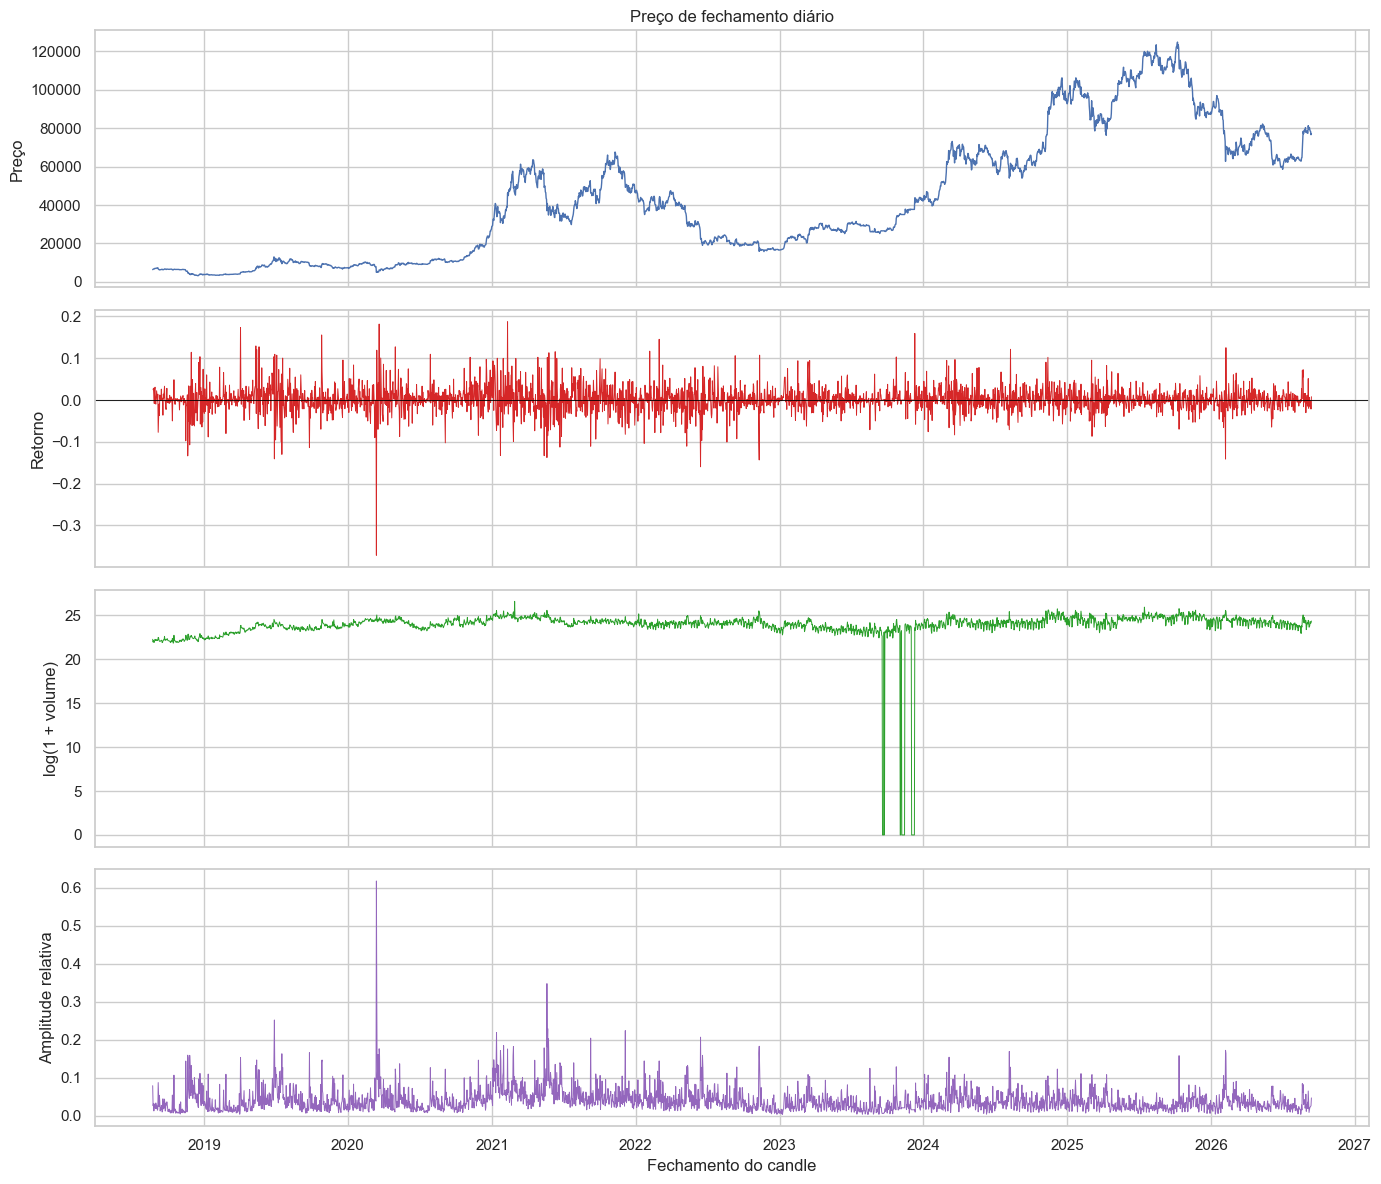

In [21]:
numeric_data = data[model_columns]
returns = data[TARGET].pct_change()
log_volume = np.log1p(data['volume'])

def iqr_outlier_mask(series):
    clean = series.dropna()
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

outlier_summary = pd.DataFrame({
    'variavel': ['retorno_diario', 'log_volume'],
    'quantidade_atipicos_IQR': [
        int(iqr_outlier_mask(returns).sum()),
        int(iqr_outlier_mask(log_volume).sum()),
    ],
    'tratamento': ['mantidos', 'mantidos; log1p nas features'],
})
display(numeric_data.describe().T, numeric_data.corr().round(3), outlier_summary)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(data.index, data[TARGET], linewidth=1)
axes[0].set(title='Preço de fechamento diário', ylabel='Preço')
axes[1].plot(data.index, returns, linewidth=0.7, color='tab:red')
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_ylabel('Retorno')
axes[2].plot(data.index, log_volume, linewidth=0.7, color='tab:green')
axes[2].set_ylabel('log(1 + volume)')
axes[3].plot(data.index, (data.priceHigh - data.priceLow) / data.priceClose,
             linewidth=0.7, color='tab:purple')
axes[3].set(xlabel='Fechamento do candle', ylabel='Amplitude relativa')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Decomposição STL e força da sazonalidade

A força sazonal é calculada por $F_S=\max(0, 1-\mathrm{Var}(R_t)/\mathrm{Var}(S_t+R_t))$. Períodos entre 7 e 365 dias são comparados. A decomposição de maior força é mostrada, mas a escolha do período semanal dos modelos permanece uma hipótese operacional definida antes do teste, não uma seleção pelo desempenho final.

,periodicidade,periodo_dias,forca_sazonal
0,Semanal,7,0.000000
1,Quinzenal,15,0.000000
2,Mensal,30,0.000000
3,Bimestral,60,0.000000
4,Trimestral,90,0.000000
5,Semestral,182,0.004963
6,Anual,365,0.000000


Maior força: Semestral (182 dias) = 0.005. Variação da tendência no período = 51,909.85; desvio-padrão residual = 7,961.98.
Interpretação: sazonalidade fraca; tendência e choques dominam a série.


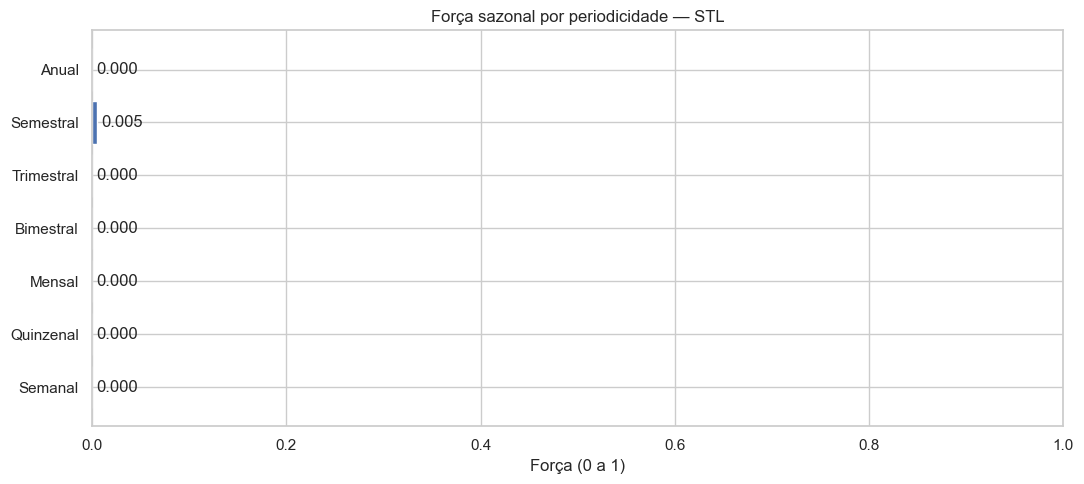

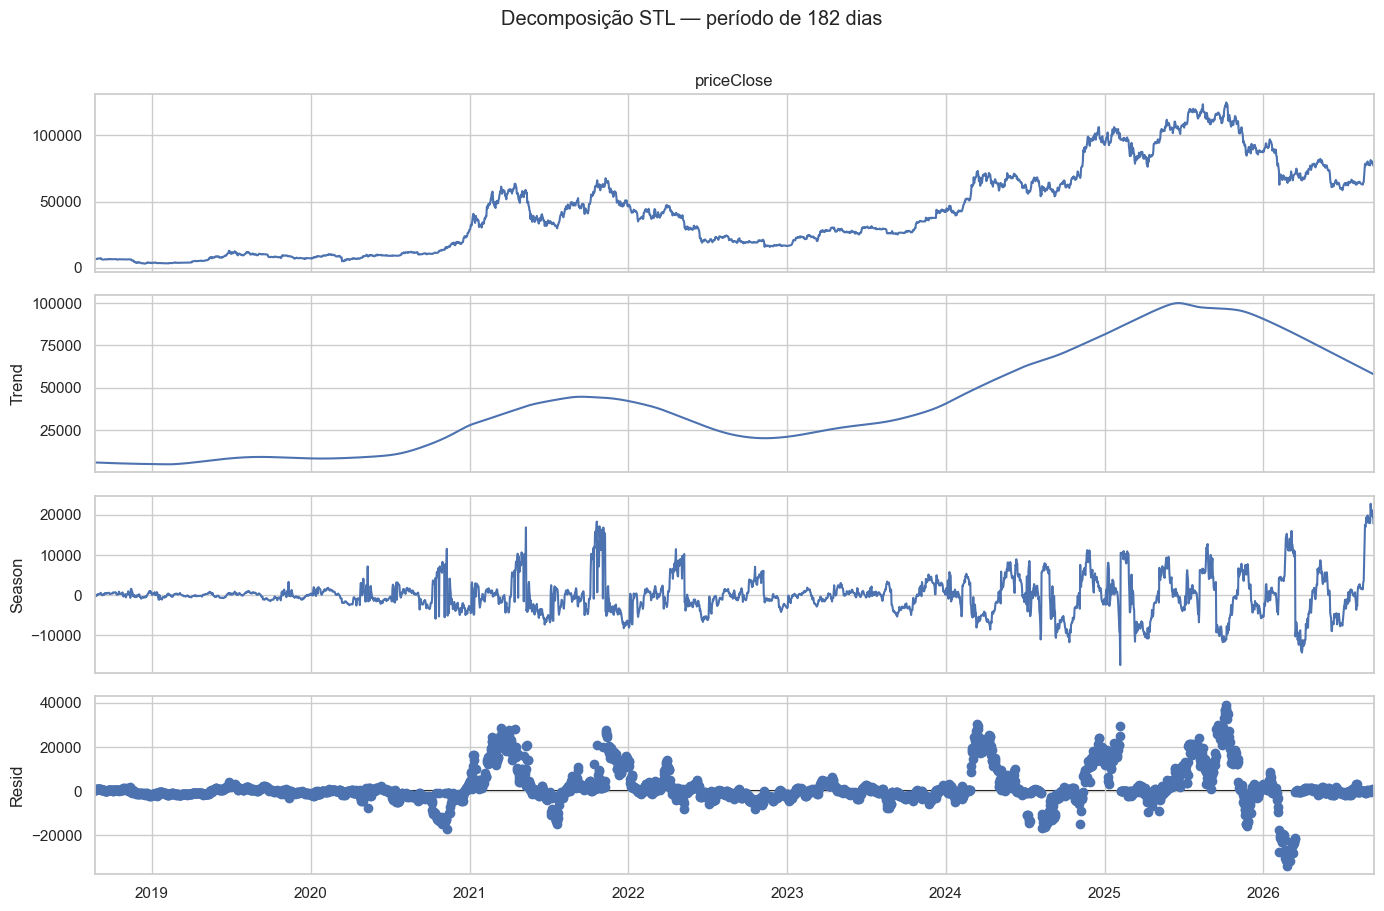

In [22]:
def fit_stl_and_measure_strength(series, period):
    result = STL(series, period=period, robust=True).fit()
    denominator = np.var(result.seasonal + result.resid)
    strength = 0.0 if denominator == 0 else max(
        0.0, 1 - np.var(result.resid) / denominator
    )
    return result, float(strength)

stl_results, seasonality_rows = {}, []
for period_name, period_days in STL_PERIODS.items():
    result, strength = fit_stl_and_measure_strength(data[TARGET], period_days)
    stl_results[period_days] = result
    seasonality_rows.append({
        'periodicidade': period_name,
        'periodo_dias': period_days,
        'forca_sazonal': strength,
    })

seasonality_comparison = pd.DataFrame(seasonality_rows).sort_values('periodo_dias')
best_period_row = seasonality_comparison.loc[seasonality_comparison.forca_sazonal.idxmax()]
best_period_days = int(best_period_row.periodo_dias)
best_stl_result = stl_results[best_period_days]
display(seasonality_comparison)

trend_change = best_stl_result.trend.iloc[-1] - best_stl_result.trend.iloc[0]
residual_scale = np.std(best_stl_result.resid)
print(
    f"Maior força: {best_period_row.periodicidade} ({best_period_days} dias) = "
    f"{best_period_row.forca_sazonal:.3f}. Variação da tendência no período = "
    f"{trend_change:,.2f}; desvio-padrão residual = {residual_scale:,.2f}."
)
if best_period_row.forca_sazonal < 0.2:
    print('Interpretação: sazonalidade fraca; tendência e choques dominam a série.')

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(seasonality_comparison.periodicidade,
               seasonality_comparison.forca_sazonal)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set(title='Força sazonal por periodicidade — STL', xlabel='Força (0 a 1)', xlim=(0, 1))
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_stl_forcas.png', dpi=150, bbox_inches='tight')
plt.show()

fig = best_stl_result.plot()
fig.set_size_inches(14, 9)
fig.suptitle(f'Decomposição STL — período de {best_period_days} dias', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_stl_melhor_periodo.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature engineering sem vazamento

Cada linha corresponde à origem `t`; o alvo e a data prevista são deslocados para `t+1`. Lags e janelas terminam em `t`. OHLCV pertence ao candle já encerrado, e o calendário usa deliberadamente a data conhecida de `t+1`. Os nulos iniciais produzidos pela maior janela (30 dias) são removidos; valores infinitos são tratados antes dessa remoção. Random Forest e SVR recebem exatamente as mesmas features.

In [23]:
def build_features(frame):
    close = frame[TARGET]
    features = pd.DataFrame(index=frame.index)

    for lag in [1, 2, 3, 7, 14, 30]:
        features[f'close_lag_{lag}'] = close.shift(lag - 1)

    features['return_1d'] = close.pct_change()
    features['return_7d'] = close.pct_change(7)
    for window in [7, 14, 30]:
        features[f'rolling_mean_{window}'] = close.rolling(window).mean()
        features[f'rolling_std_{window}'] = close.rolling(window).std()

    features['intraday_range'] = (frame.priceHigh - frame.priceLow) / close
    features['open_close_change'] = (close - frame.priceOpen) / frame.priceOpen
    features['log_volume'] = np.log1p(frame.volume)
    features['log_volume_change_1d'] = features.log_volume.diff()
    features['imputado'] = frame.imputado.astype(int)

    target_date = frame.index.to_series().shift(-HORIZON)
    target_day_of_week = pd.DatetimeIndex(target_date).dayofweek
    features['target_dow_sin'] = np.sin(2 * np.pi * target_day_of_week / 7)
    features['target_dow_cos'] = np.cos(2 * np.pi * target_day_of_week / 7)
    features['target'] = close.shift(-HORIZON)
    features['target_date'] = target_date

    return features.replace([np.inf, -np.inf], np.nan).dropna()

supervised = build_features(data)
feature_columns = [c for c in supervised if c not in ['target', 'target_date']]
X = supervised[feature_columns].astype(float)
y_ml = supervised.target.astype(float)
target_dates_ml = pd.DatetimeIndex(supervised.target_date)

# Covariáveis exógenas parcimoniosas do SARIMAX: todas conhecidas em t para prever t+1.
sarimax_exog_columns = [
    'return_1d', 'intraday_range', 'open_close_change',
    'log_volume_change_1d', 'target_dow_sin', 'target_dow_cos',
]
print(f'{len(supervised):,} linhas e {len(feature_columns)} features')
display(supervised.head(3))

2,913 linhas e 21 features


,close_lag_1,close_lag_2,close_lag_3,close_lag_7,close_lag_14,close_lag_30,return_1d,return_7d,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,intraday_range,open_close_change,log_volume,log_volume_change_1d,imputado,target_dow_sin,target_dow_cos,target,target_date
data_fechamento,,,,,,,,,,,,,,,,,,,,,,,
2018-09-21 11:59:59.999000+00:00,6519.67,6398.54,6371.30,6512.71,6467.07,6376.71,0.018931,0.000362,6449.114286,99.428044,6404.122857,106.630067,6673.776667,340.010044,0.020447,0.018882,22.193007,-0.018961,0,-0.974928,-0.222521,6734.95,2018-09-22 11:59:59.999000+00:00
2018-09-22 11:59:59.999000+00:00,6734.95,6519.67,6398.54,6543.20,6225.98,6534.88,0.033020,0.034124,6480.862857,147.149274,6423.257143,138.166062,6685.718000,335.477723,0.044242,0.033940,22.599970,0.406963,0,-0.781831,0.623490,6721.98,2018-09-23 11:59:59.999000+00:00
2018-09-23 11:59:59.999000+00:00,6721.98,6734.95,6519.67,6517.18,6300.86,6719.96,-0.001926,0.027323,6506.402857,173.013954,6458.685714,146.998873,6691.954667,334.314003,0.029420,-0.001941,22.229488,-0.370482,0,0.000000,1.000000,6710.63,2018-09-24 11:59:59.999000+00:00


## 7. Divisão temporal e protocolo walk-forward

O último ano (365 observações) é o teste comum. Os 60 últimos dias do pré-teste formam a validação dos modelos clássicos; Random Forest e SVR usam `TimeSeriesSplit` expansivo dentro do pré-teste. No teste, os hiperparâmetros ficam fixos e cada modelo é reestimado/atualizado a cada origem com somente os valores já observados. As covariáveis do SARIMAX são padronizadas com estatísticas do respectivo treino.

In [24]:
if len(X) <= TEST_SIZE + VALIDATION_SIZE + 2 * MODEL_SEASONAL_PERIOD:
    raise ValueError('Série insuficiente para o protocolo definido.')

train_size = len(X) - TEST_SIZE
origin_dates = X.index[train_size:]
prediction_dates = target_dates_ml[train_size:]

# Série e exógenas alinhadas pela data prevista, não pela origem.
target_series = pd.Series(y_ml.to_numpy(), index=target_dates_ml, name=TARGET)
exog_by_prediction_date = X[sarimax_exog_columns].copy()
exog_by_prediction_date.index = target_dates_ml

classical_pretest = target_series.iloc[:train_size]
classical_test = target_series.iloc[train_size:]
classical_tune_train = classical_pretest.iloc[:-VALIDATION_SIZE]
classical_val = classical_pretest.iloc[-VALIDATION_SIZE:]

exog_pretest_raw = exog_by_prediction_date.iloc[:train_size]
exog_test_raw = exog_by_prediction_date.iloc[train_size:]
exog_tune_train_raw = exog_pretest_raw.iloc[:-VALIDATION_SIZE]
exog_val_raw = exog_pretest_raw.iloc[-VALIDATION_SIZE:]

validation_exog_scaler = StandardScaler().fit(exog_tune_train_raw)
exog_tune_train = pd.DataFrame(
    validation_exog_scaler.transform(exog_tune_train_raw),
    index=exog_tune_train_raw.index, columns=sarimax_exog_columns,
)
exog_val = pd.DataFrame(
    validation_exog_scaler.transform(exog_val_raw),
    index=exog_val_raw.index, columns=sarimax_exog_columns,
)

final_exog_scaler = StandardScaler().fit(exog_pretest_raw)
exog_pretest = pd.DataFrame(
    final_exog_scaler.transform(exog_pretest_raw),
    index=exog_pretest_raw.index, columns=sarimax_exog_columns,
)
exog_test = pd.DataFrame(
    final_exog_scaler.transform(exog_test_raw),
    index=exog_test_raw.index, columns=sarimax_exog_columns,
)

X_pretest, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_pretest, y_test = y_ml.iloc[:train_size], y_ml.iloc[train_size:]

assert classical_test.index.equals(prediction_dates)
assert X_test.index.equals(origin_dates)
assert (prediction_dates > origin_dates).all()

split_summary = pd.DataFrame({
    'bloco': ['treino clássico', 'validação clássica', 'pré-teste ML', 'teste comum'],
    'inicio': [classical_tune_train.index.min(), classical_val.index.min(),
               X_pretest.index.min(), prediction_dates.min()],
    'fim': [classical_tune_train.index.max(), classical_val.index.max(),
            X_pretest.index.max(), prediction_dates.max()],
    'n': [len(classical_tune_train), len(classical_val), len(X_pretest), TEST_SIZE],
})
display(split_summary)

,bloco,inicio,fim,n
0,treino clássico,2018-09-22 11:59:59.999000+00:00,2025-07-14 11:59:59.999000+00:00,2488
1,validação clássica,2025-07-15 11:59:59.999000+00:00,2025-09-12 11:59:59.999000+00:00,60
2,pré-teste ML,2018-09-21 11:59:59.999000+00:00,2025-09-11 11:59:59.999000+00:00,2548
3,teste comum,2025-09-13 11:59:59.999000+00:00,2026-09-12 11:59:59.999000+00:00,365


## 8. Seleção de hiperparâmetros somente no pré-teste

- **SARIMAX:** busca `p,d,q,P,D,Q ∈ {0,1}`, com período semanal e covariáveis exógenas. A decisão usa MAE walk-forward na validação; AIC/BIC e convergência também são registrados.
- **Holt-Winters:** compara tendência aditiva/multiplicativa, sazonalidade aditiva/multiplicativa, tendência amortecida e períodos 7/30. Os parâmetros de suavização são estimados em cada treino e registrados no ajuste final.
- **Random Forest:** pesquisa `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` e `max_features`.
- **SVR:** pesquisa `C`, `epsilon` e `gamma` com kernel RBF. `X` e `y` são padronizados dentro de cada fold.

Em todos os casos, o teste final não participa da seleção.

In [25]:
def sarimax_walk(train, observed, exog_train, exog_observed, order, seasonal_order):
    fitted_model = SARIMAX(
        train, exog=exog_train, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False, maxiter=150)

    diagnostics = {
        'aic_treino': float(fitted_model.aic),
        'bic_treino': float(fitted_model.bic),
        'convergiu': bool(fitted_model.mle_retvals.get('converged', True)),
    }
    predictions = []
    for date, actual_value in observed.items():
        next_exog = exog_observed.loc[[date]]
        predictions.append(float(fitted_model.forecast(1, exog=next_exog).iloc[0]))
        new_observation = pd.Series([float(actual_value)], index=[date], name=train.name)
        fitted_model = fitted_model.append(
            new_observation, exog=next_exog, refit=False,
        )
    return np.asarray(predictions), fitted_model, diagnostics


def holt_winters_walk(train, observed, trend, seasonal, damped_trend, seasonal_periods):
    history, predictions, fitted_model = train.copy(), [], None
    for date, actual_value in observed.items():
        fitted_model = ExponentialSmoothing(
            history, trend=trend, seasonal=seasonal,
            damped_trend=damped_trend,
            seasonal_periods=seasonal_periods if seasonal else None,
            initialization_method='estimated',
        ).fit(optimized=True, use_brute=False)
        predictions.append(float(fitted_model.forecast(1).iloc[0]))
        history.loc[date] = float(actual_value)
    return np.asarray(predictions), fitted_model


sarimax_candidates = []
for p, d, q, P, D, Q in product(range(2), repeat=6):
    seasonal_order = (P, D, Q, MODEL_SEASONAL_PERIOD) if any((P, D, Q)) else (0, 0, 0, 0)
    sarimax_candidates.append({'order': (p, d, q), 'seasonal_order': seasonal_order})

sarimax_scores = []
for parameters in sarimax_candidates:
    try:
        val_pred, _, diagnostics = sarimax_walk(
            classical_tune_train, classical_val,
            exog_tune_train, exog_val, **parameters,
        )
        valid = bool(np.isfinite(val_pred).all() and diagnostics['convergiu'])
        sarimax_scores.append({
            **parameters, **diagnostics,
            'mae_validacao': mean_absolute_error(classical_val, val_pred) if valid else np.inf,
            'valido': valid, 'erro': None,
        })
    except Exception as error:
        sarimax_scores.append({
            **parameters, 'aic_treino': np.nan, 'bic_treino': np.nan,
            'convergiu': False, 'mae_validacao': np.inf,
            'valido': False, 'erro': str(error)[:200],
        })

sarimax_tuning = pd.DataFrame(sarimax_scores).sort_values(
    ['mae_validacao', 'aic_treino'], ignore_index=True,
)
valid_sarimax_tuning = sarimax_tuning[sarimax_tuning.valido]
if valid_sarimax_tuning.empty:
    raise RuntimeError('Nenhuma combinação SARIMAX válida.')
best_sarimax = valid_sarimax_tuning.iloc[0][['order', 'seasonal_order']].to_dict()

holt_winters_candidates = []
for trend in [None, 'add', 'mul']:
    for seasonal in [None, 'add', 'mul']:
        if trend is None and seasonal is None:
            continue
        for damped in ([False, True] if trend else [False]):
            for seasonal_period in ([7, 30] if seasonal else [None]):
                holt_winters_candidates.append({
                    'trend': trend, 'seasonal': seasonal,
                    'damped_trend': damped, 'seasonal_periods': seasonal_period,
                })

holt_winters_scores = []
for parameters in holt_winters_candidates:
    try:
        val_pred, val_fit = holt_winters_walk(
            classical_tune_train, classical_val, **parameters,
        )
        holt_winters_scores.append({
            **parameters,
            'mae_validacao': mean_absolute_error(classical_val, val_pred),
            'smoothing_level': val_fit.params.get('smoothing_level'),
            'smoothing_trend': val_fit.params.get('smoothing_trend'),
            'smoothing_seasonal': val_fit.params.get('smoothing_seasonal'),
            'damping_trend': val_fit.params.get('damping_trend'),
            'erro': None,
        })
    except Exception as error:
        holt_winters_scores.append({
            **parameters, 'mae_validacao': np.inf,
            'smoothing_level': np.nan, 'smoothing_trend': np.nan,
            'smoothing_seasonal': np.nan, 'damping_trend': np.nan,
            'erro': str(error)[:200],
        })

hw_tuning = pd.DataFrame(holt_winters_scores).sort_values('mae_validacao', ignore_index=True)
best_hw = {
    key: (None if pd.isna(value) else value)
    for key, value in hw_tuning.iloc[0][
        ['trend', 'seasonal', 'damped_trend', 'seasonal_periods']
    ].to_dict().items()
}
best_hw['damped_trend'] = bool(best_hw['damped_trend'])
display(sarimax_tuning.head(15), hw_tuning.head(15))

,order,seasonal_order,aic_treino,bic_treino,convergiu,mae_validacao,valido,erro
0,"(1, 0, 1)","(0, 1, 1, 7)",43364.686886,43422.814714,True,1330.815056,True,None
1,"(1, 1, 0)","(0, 1, 1, 7)",42524.333172,42576.648217,True,1338.463473,True,None
2,"(1, 1, 0)","(1, 1, 1, 7)",42526.332039,42584.459867,True,1338.519285,True,None
3,"(0, 1, 1)","(0, 1, 1, 7)",42508.198865,42560.510269,True,1338.523419,True,None
4,"(0, 1, 1)","(1, 1, 1, 7)",42510.197544,42568.321326,True,1338.591341,True,None
5,"(0, 1, 1)","(0, 0, 0, 0)",42707.027738,42753.571961,True,1338.689628,True,None
6,"(1, 1, 1)","(1, 1, 1, 7)",42512.051343,42575.987503,True,1339.288691,True,None
7,"(1, 1, 1)","(0, 1, 1, 7)",42510.050091,42568.173873,True,1339.324391,True,None
8,"(1, 1, 1)","(0, 0, 0, 0)",42710.133903,42762.496154,True,1340.422093,True,None
9,"(1, 1, 1)","(0, 0, 1, 7)",42598.813447,42656.965517,True,1340.508665,True,None


,trend,seasonal,damped_trend,seasonal_periods,mae_validacao,smoothing_level,smoothing_trend,smoothing_seasonal,damping_trend,erro
0,NaN,mul,False,7.0,1328.965896,1.000000,NaN,4.726693e-09,NaN,NaN
1,add,mul,True,7.0,1328.998394,0.935545,0.007505,0.000000e+00,0.968326,NaN
2,NaN,add,False,7.0,1335.391820,0.997647,NaN,1.953042e-03,NaN,NaN
3,NaN,add,False,30.0,1337.183808,0.942266,NaN,0.000000e+00,NaN,NaN
4,add,add,False,30.0,1339.767764,0.941073,0.000000,0.000000e+00,NaN,NaN
5,add,add,False,7.0,1342.725495,0.938856,0.000000,1.582403e-03,NaN,NaN
6,add,NaN,False,NaN,1345.258908,0.937511,0.000000,NaN,NaN,NaN
7,add,add,True,7.0,1347.629223,0.933314,0.007461,0.000000e+00,0.968511,NaN
8,add,NaN,True,NaN,1347.925979,0.930588,0.007571,NaN,0.968356,NaN
9,mul,NaN,True,NaN,1348.168423,0.929531,0.008116,NaN,0.965142,NaN


In [26]:
time_series_cv = TimeSeriesSplit(n_splits=3)

random_forest_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
random_forest_parameters = {
    'n_estimators': [50, 100],
    'max_depth': [8, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 0.8],
}
rf_grid = GridSearchCV(
    random_forest_model, random_forest_parameters,
    scoring='neg_mean_absolute_error', cv=time_series_cv, n_jobs=1,
).fit(X_pretest, y_pretest)

svr_model = TransformedTargetRegressor(
    regressor=Pipeline([('scale', StandardScaler()), ('svr', SVR(kernel='rbf'))]),
    transformer=StandardScaler(),
)
svr_parameters = {
    'regressor__svr__C': [1, 10, 100],
    'regressor__svr__epsilon': [0.01, 0.1, 0.5],
    'regressor__svr__gamma': ['scale', 0.01, 0.1],
}
svr_grid = GridSearchCV(
    svr_model, svr_parameters, scoring='neg_mean_absolute_error',
    cv=time_series_cv, n_jobs=1,
).fit(X_pretest, y_pretest)

cv_summary = pd.DataFrame([
    {'modelo': 'Random Forest', 'mae_cv': -rf_grid.best_score_, 'parametros': rf_grid.best_params_},
    {'modelo': 'SVR', 'mae_cv': -svr_grid.best_score_, 'parametros': svr_grid.best_params_},
])
display(cv_summary)

,modelo,mae_cv,parametros
0,Random Forest,15449.301627,"{'max_depth': None, 'max_features': 0.8, 'min_..."
1,SVR,15871.763190,"{'regressor__svr__C': 10, 'regressor__svr__eps..."


## 9. Previsões do SARIMAX com variáveis externas

O SARIMAX é ajustado no pré-teste com seis covariáveis disponíveis na origem. A cada passo, prevê `t+1` e recebe o valor real e as covariáveis correspondentes sem reotimizar hiperparâmetros. Os coeficientes exógenos padronizados, sinais e p-valores serão exportados para interpretação.

In [27]:
predictions_by_model, elapsed_by_model, fitted_by_model = {}, {}, {}

start_time = perf_counter()
predictions_by_model['SARIMAX'], fitted_by_model['SARIMAX'], _ = sarimax_walk(
    classical_pretest, classical_test, exog_pretest, exog_test, **best_sarimax,
)
elapsed_by_model['SARIMAX'] = perf_counter() - start_time
print('Melhores parâmetros:', best_sarimax)
print(f"Tempo: {elapsed_by_model['SARIMAX']:.1f}s")

Melhores parâmetros: {'order': (1, 0, 1), 'seasonal_order': (0, 1, 1, 7)}
Tempo: 61.9s


## 10. Previsões do Holt-Winters

Referência estritamente univariada: não recebe covariáveis. É reestimado em cada origem com o histórico disponível e com a configuração escolhida na validação.

In [28]:
start_time = perf_counter()
predictions_by_model['Holt-Winters'], fitted_by_model['Holt-Winters'] = holt_winters_walk(
    classical_pretest, classical_test, **best_hw,
)
elapsed_by_model['Holt-Winters'] = perf_counter() - start_time
print('Melhores parâmetros:', best_hw)
print(f"Tempo: {elapsed_by_model['Holt-Winters']:.1f}s")

Melhores parâmetros: {'trend': None, 'seasonal': 'mul', 'damped_trend': False, 'seasonal_periods': 7.0}
Tempo: 47.4s


## 11. Walk-forward dos modelos tabulares

Random Forest e SVR usam a mesma matriz de features. Em cada origem, o estimador é refeito com a janela expansiva completa; portanto, a observação real recém-chegada entra no treino seguinte. Os hiperparâmetros escolhidos continuam fixos.

In [29]:
def machine_learning_walk(best_estimator):
    predictions, fitted_model = [], None
    for step, position in enumerate(range(train_size, len(X))):
        if step % ML_REFIT_EVERY == 0:
            fitted_model = clone(best_estimator).fit(X.iloc[:position], y_ml.iloc[:position])
        predictions.append(float(fitted_model.predict(X.iloc[[position]])[0]))
    return np.asarray(predictions), fitted_model

start_time = perf_counter()
predictions_by_model['Random Forest'], fitted_by_model['Random Forest'] = (
    machine_learning_walk(rf_grid.best_estimator_)
)
elapsed_by_model['Random Forest'] = perf_counter() - start_time
print('Melhores parâmetros:', rf_grid.best_params_)
print(f"Tempo: {elapsed_by_model['Random Forest']:.1f}s")

Melhores parâmetros: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Tempo: 5365.7s


## 12. SVR: estudo do modelo de especialização

O SVR procura uma função que mantenha erros dentro de um tubo de largura `epsilon`; somente observações fora desse tubo se tornam vetores de suporte. Com kernel RBF, relações não lineares são representadas por similaridade no espaço transformado.

- **Preparação:** SVR é sensível à escala. `StandardScaler` é ajustado dentro de cada treino para as entradas e para o alvo, evitando vazamento.
- **`C`:** penalização por erros fora do tubo; valores altos priorizam ajuste e podem aumentar variância.
- **`epsilon`:** largura do tubo sem penalidade; valores maiores deixam o ajuste mais suave.
- **`gamma`:** alcance do kernel RBF; valores altos geram fronteiras mais locais e risco de sobreajuste.
- **Vantagens:** flexibilidade não linear e solução convexa para hiperparâmetros fixos.
- **Limitações:** custo crescente com a amostra, forte dependência de escala/parâmetros e ausência de importância nativa.
- **Otimização:** busca em grade com validação temporal expansiva e MAE.
- **Interpretação:** permutation importance mede o aumento do MAE ao embaralhar cada feature no teste, sem retreinar.

In [30]:
start_time = perf_counter()
predictions_by_model['SVR'], fitted_by_model['SVR'] = machine_learning_walk(
    svr_grid.best_estimator_
)
elapsed_by_model['SVR'] = perf_counter() - start_time
print('Melhores parâmetros:', svr_grid.best_params_)
print(f"Tempo: {elapsed_by_model['SVR']:.1f}s")

Melhores parâmetros: {'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.01}
Tempo: 56.2s


## 13. Comparação por MAE

Todos os modelos são avaliados nas mesmas 365 datas previstas. O resíduo é `real − previsto`; menor MAE é melhor. MAEs desta base não devem ser somados aos de bases com outras escalas.

,base,modelo,mae,tempo_segundos,n_teste,horizonte,hiperparametros,rank_mae
0,base_01,Holt-Winters,1317.713701,47.391604,365,1,"{'trend': None, 'seasonal': 'mul', 'damped_tre...",1
1,base_01,SARIMAX,1363.065886,61.876655,365,1,"{'order': (1, 0, 1), 'seasonal_order': (0, 1, ...",2
2,base_01,Random Forest,1524.471983,5365.686804,365,1,"{'max_depth': None, 'max_features': 0.8, 'min_...",3
3,base_01,SVR,1595.297169,56.190549,365,1,"{'regressor__svr__C': 10, 'regressor__svr__eps...",4


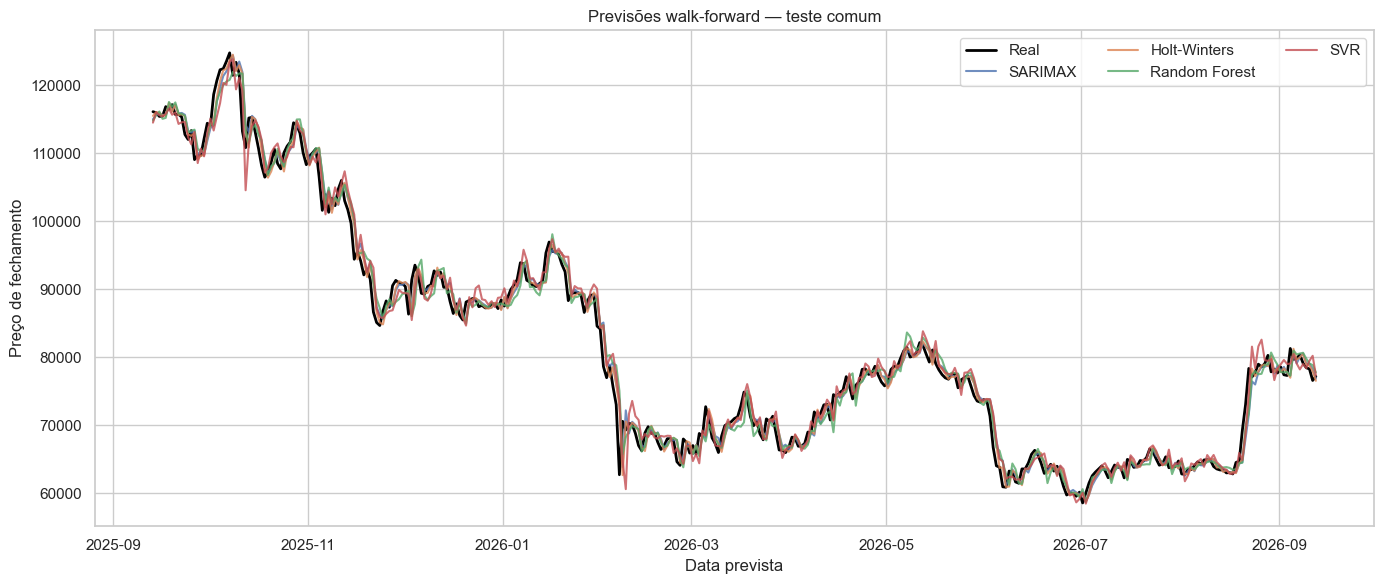

In [31]:
actual_values = classical_test.to_numpy(dtype=float)
prediction_frames, metric_rows = [], []
parameters_by_model = {
    'SARIMAX': {**best_sarimax, 'exog': sarimax_exog_columns},
    'Holt-Winters': best_hw,
    'Random Forest': rf_grid.best_params_,
    'SVR': svr_grid.best_params_,
}

for model_name, predicted_values in predictions_by_model.items():
    model_residuals = actual_values - predicted_values
    prediction_frames.append(pd.DataFrame({
        'base': BASE_ID, 'modelo': model_name,
        'data_origem': origin_dates, 'data_prevista': prediction_dates,
        'horizonte': HORIZON, 'valor_real': actual_values,
        'valor_previsto': predicted_values, 'residuo': model_residuals,
    }))
    metric_rows.append({
        'base': BASE_ID, 'modelo': model_name,
        'mae': mean_absolute_error(actual_values, predicted_values),
        'tempo_segundos': elapsed_by_model[model_name],
        'n_teste': TEST_SIZE, 'horizonte': HORIZON,
        'hiperparametros': repr(parameters_by_model[model_name]),
    })

predictions = pd.concat(prediction_frames, ignore_index=True)
metrics = pd.DataFrame(metric_rows).sort_values('mae', ignore_index=True)
metrics['rank_mae'] = metrics.mae.rank(method='min').astype(int)
display(metrics)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prediction_dates, actual_values, label='Real', color='black', linewidth=2)
for model_name, predicted_values in predictions_by_model.items():
    ax.plot(prediction_dates, predicted_values, label=model_name, alpha=0.8)
ax.set(title='Previsões walk-forward — teste comum', xlabel='Data prevista', ylabel='Preço de fechamento')
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_previsoes.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Diagnóstico dos resíduos fora da amostra

Cada linha abaixo combina o gráfico temporal dos erros e sua ACF. O teste de Ljung–Box avalia autocorrelação conjunta até o lag 10: `p > 0,05` significa ausência de evidência suficiente contra resíduos não autocorrelacionados; não prova independência.

,modelo,residuo_medio,desvio_residuo,ljung_box_lag,ljung_box_stat,ljung_box_pvalue,residuos_brancos_5pct
0,SARIMAX,-166.142909,1934.979951,10,40.600336,0.000013,False
1,Holt-Winters,-106.773641,1858.018339,10,12.184963,0.272868,True
2,Random Forest,-86.581854,2108.922030,10,45.068488,0.000002,False
3,SVR,-324.207543,2158.444387,10,24.202406,0.007081,False


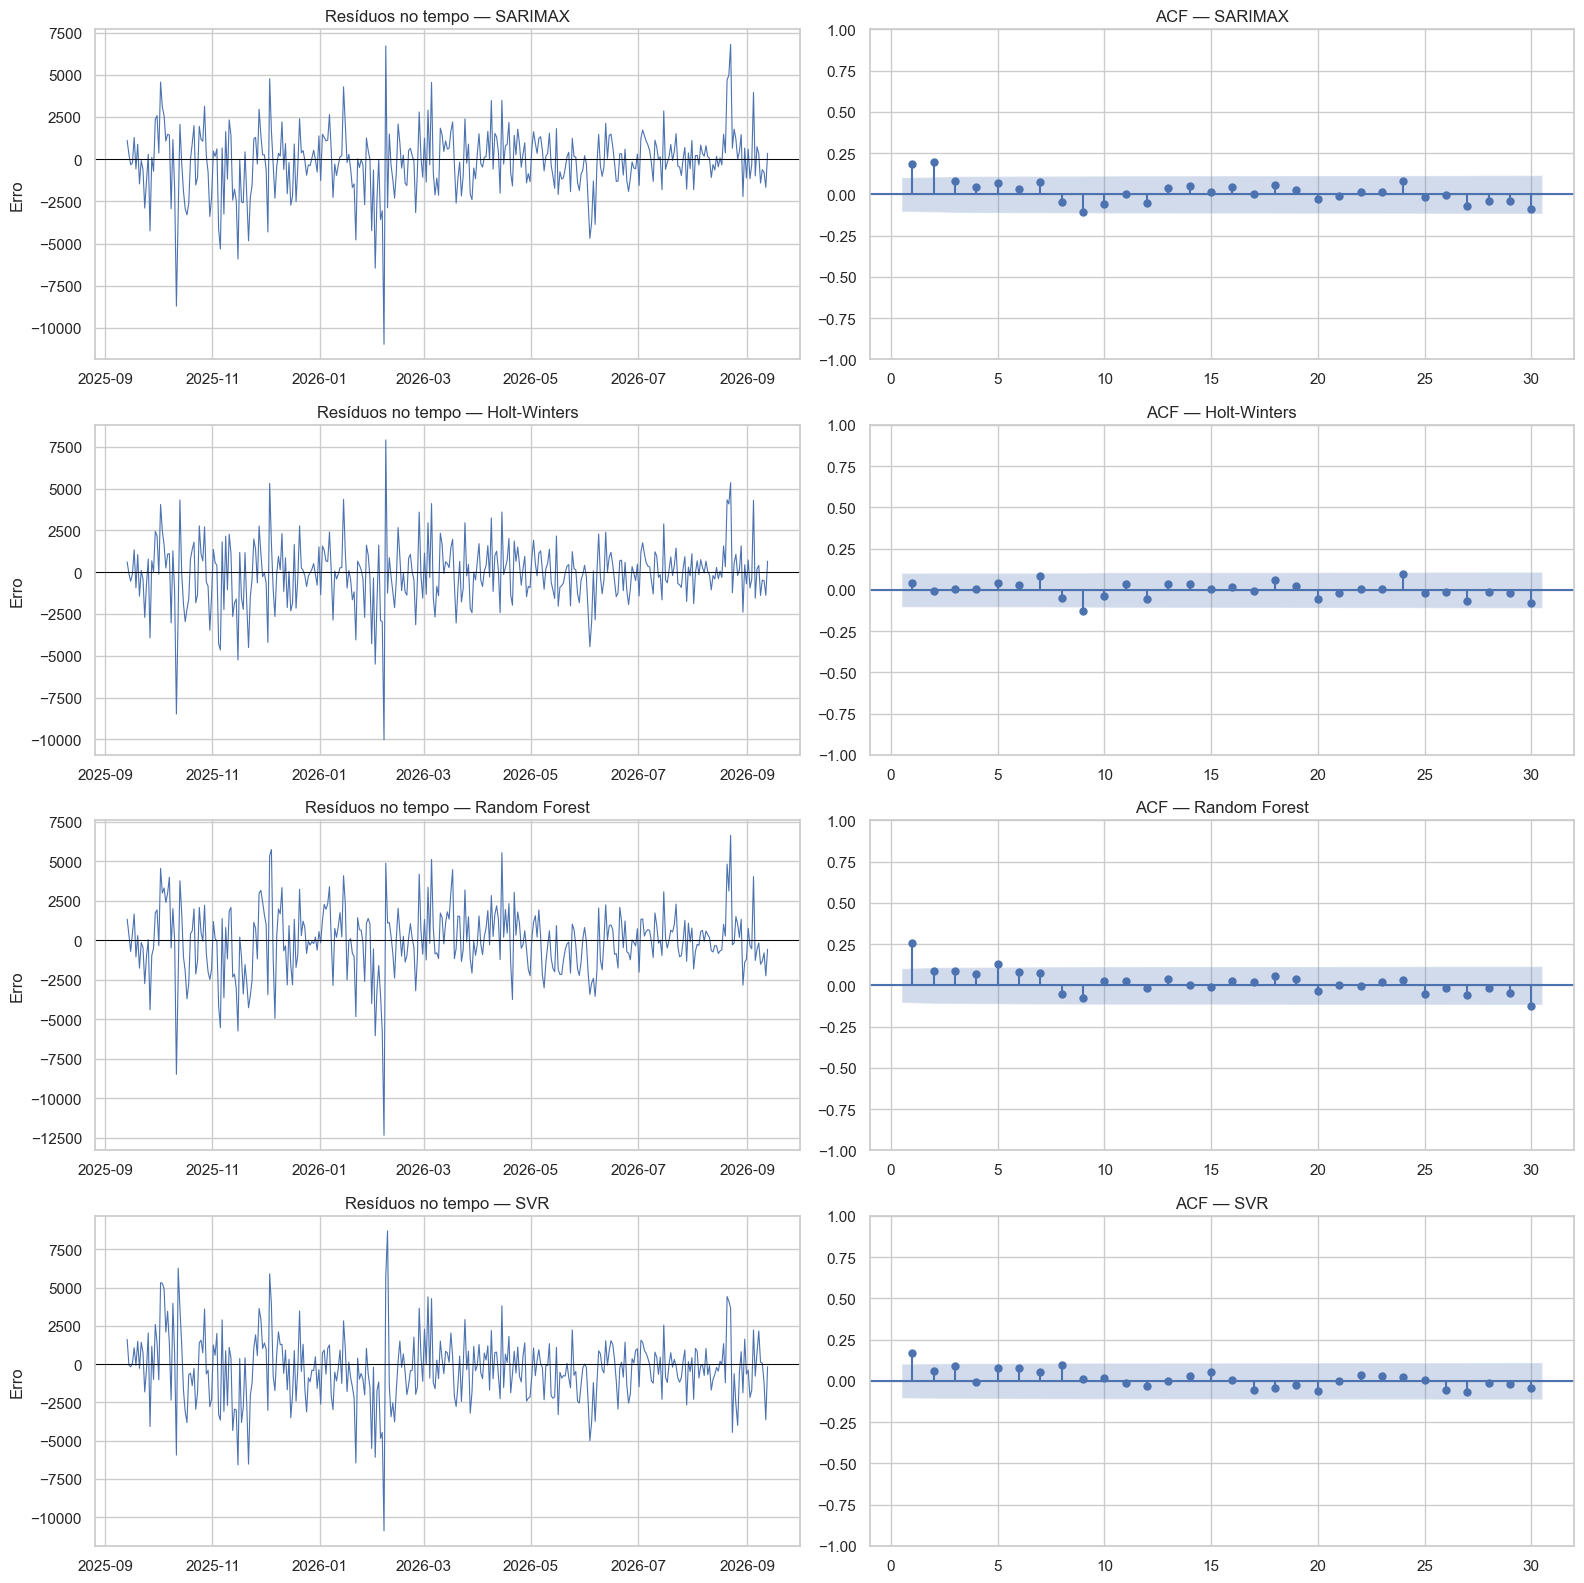

In [32]:
residual_frames, diagnostic_rows = [], []
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

for row, (model_name, predicted_values) in enumerate(predictions_by_model.items()):
    model_residuals = actual_values - predicted_values
    ljung_box = acorr_ljungbox(model_residuals, lags=[LJUNG_BOX_LAG], return_df=True).iloc[0]
    residuals_are_white = bool(ljung_box.lb_pvalue > 0.05)
    diagnostic_rows.append({
        'modelo': model_name, 'residuo_medio': np.mean(model_residuals),
        'desvio_residuo': np.std(model_residuals, ddof=1),
        'ljung_box_lag': LJUNG_BOX_LAG, 'ljung_box_stat': ljung_box.lb_stat,
        'ljung_box_pvalue': ljung_box.lb_pvalue,
        'residuos_brancos_5pct': residuals_are_white,
    })
    residual_frames.append(pd.DataFrame({
        'base': BASE_ID, 'modelo': model_name, 'data_prevista': prediction_dates,
        'residuo': model_residuals, 'ljung_box_lag': LJUNG_BOX_LAG,
        'ljung_box_stat': ljung_box.lb_stat,
        'ljung_box_pvalue': ljung_box.lb_pvalue,
        'residuos_brancos_5pct': residuals_are_white,
    }))
    axes[row, 0].plot(prediction_dates, model_residuals, linewidth=0.8)
    axes[row, 0].axhline(0, color='black', linewidth=0.7)
    axes[row, 0].set(title=f'Resíduos no tempo — {model_name}', ylabel='Erro')
    plot_acf(model_residuals, lags=min(30, TEST_SIZE // 3), zero=False,
             ax=axes[row, 1], title=f'ACF — {model_name}')

residuals = pd.concat(residual_frames, ignore_index=True)
diagnostics = pd.DataFrame(diagnostic_rows)
metrics = metrics.merge(diagnostics, on='modelo', how='left')
display(diagnostics)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_residuos_e_acf.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Interpretação das covariáveis e importância das features

- **SARIMAX:** coeficientes das covariáveis padronizadas, sinais e p-valores.
- **Holt-Winters:** não possui feature importance; são apresentados seus parâmetros de nível, tendência e sazonalidade.
- **Random Forest e SVR:** permutation importance no teste comum usando modelos ajustados somente no pré-teste. Valores positivos indicam aumento do MAE após a permutação; valores próximos de zero ou negativos não fornecem evidência de utilidade naquele conjunto.

A análise no teste é apenas interpretativa e não retroalimenta tuning ou seleção.

,variavel,coeficiente_padronizado,erro_padrao,pvalor,significativo_5pct
0,return_1d,6.133039e+02,411.720140,1.363259e-01,False
1,intraday_range,-1.931673e+02,32.361911,2.387541e-09,True
2,open_close_change,-1.630277e+02,411.267485,6.918076e-01,False
3,log_volume_change_1d,4.513381e+01,68.468717,5.097745e-01,False
4,target_dow_sin,1.979633e-07,3492.311829,1.000000e+00,False
5,target_dow_cos,-1.037870e-06,1789.465854,1.000000e+00,False


,parametro,valor
0,smoothing_level,1.000000e+00
1,smoothing_trend,NaN
2,smoothing_seasonal,4.613778e-09
3,damping_trend,NaN


,base,modelo,feature,importance,importance_std,metodo,n_avaliacoes,rank
0,base_01,Random Forest,close_lag_1,8309.854417,331.574208,permutation_delta_mae,365,1
1,base_01,Random Forest,close_lag_2,3735.308289,236.558385,permutation_delta_mae,365,2
10,base_01,Random Forest,rolling_mean_14,347.678201,55.525701,permutation_delta_mae,365,3
8,base_01,Random Forest,rolling_mean_7,181.086167,37.213296,permutation_delta_mae,365,4
2,base_01,Random Forest,close_lag_3,115.015795,22.858811,permutation_delta_mae,365,5
5,base_01,Random Forest,close_lag_30,23.378581,2.516133,permutation_delta_mae,365,6
7,base_01,Random Forest,return_7d,15.091595,6.872907,permutation_delta_mae,365,7
12,base_01,Random Forest,rolling_mean_30,13.000128,16.324247,permutation_delta_mae,365,8
15,base_01,Random Forest,open_close_change,11.657578,2.742812,permutation_delta_mae,365,9
6,base_01,Random Forest,return_1d,9.115444,2.473174,permutation_delta_mae,365,10


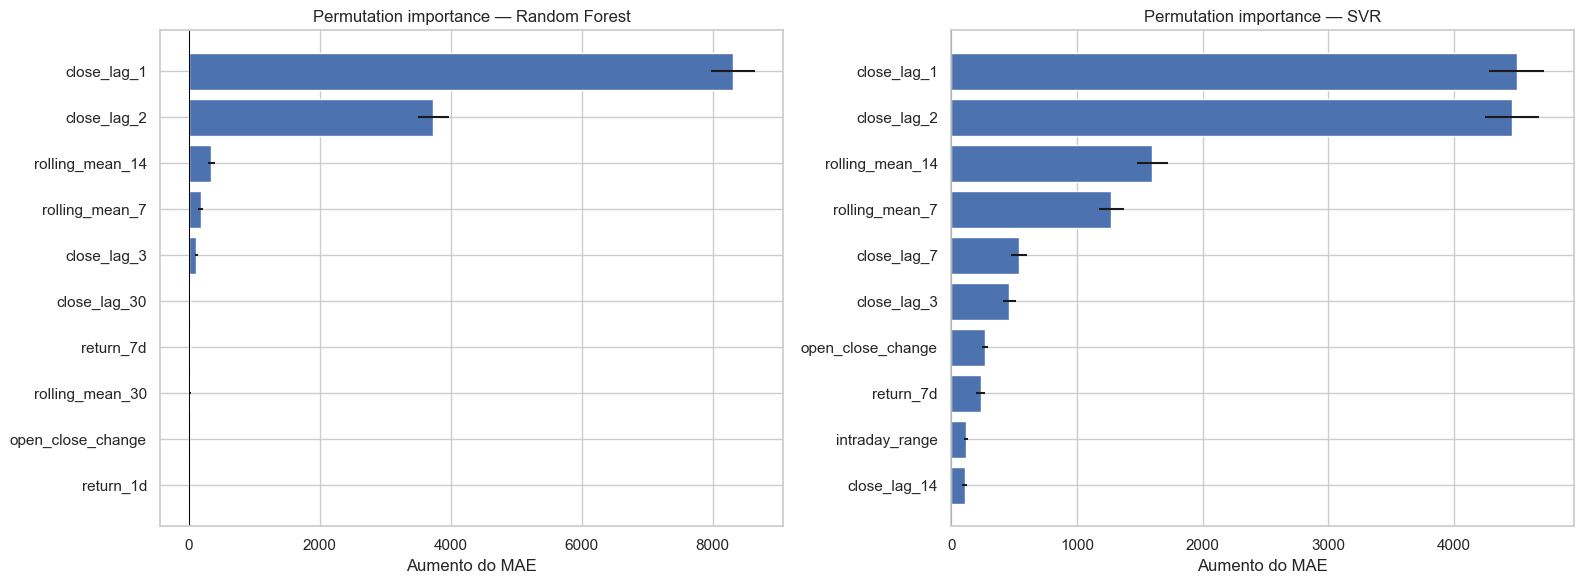

In [33]:
sarimax_fit = fitted_by_model['SARIMAX']
sarimax_coefficients = pd.DataFrame({
    'variavel': sarimax_exog_columns,
    'coeficiente_padronizado': [sarimax_fit.params[name] for name in sarimax_exog_columns],
    'erro_padrao': [sarimax_fit.bse[name] for name in sarimax_exog_columns],
    'pvalor': [sarimax_fit.pvalues[name] for name in sarimax_exog_columns],
})
sarimax_coefficients['significativo_5pct'] = sarimax_coefficients.pvalor < 0.05

hw_fit = fitted_by_model['Holt-Winters']
hw_parameters = pd.DataFrame([
    {'parametro': key, 'valor': value}
    for key, value in hw_fit.params.items()
    if np.isscalar(value) and key in {
        'smoothing_level', 'smoothing_trend', 'smoothing_seasonal', 'damping_trend'
    }
])
display(sarimax_coefficients, hw_parameters)

importance_frames = []
for model_name, estimator in [
    ('Random Forest', rf_grid.best_estimator_),
    ('SVR', svr_grid.best_estimator_),
]:
    explainer = clone(estimator).fit(X_pretest, y_pretest)
    result = permutation_importance(
        explainer, X_test, y_test, scoring='neg_mean_absolute_error',
        n_repeats=PERMUTATION_REPEATS, random_state=RANDOM_STATE, n_jobs=1,
    )
    importance_frames.append(pd.DataFrame({
        'base': BASE_ID, 'modelo': model_name, 'feature': feature_columns,
        'importance': result.importances_mean,
        'importance_std': result.importances_std,
        'metodo': 'permutation_delta_mae', 'n_avaliacoes': len(X_test),
    }))

feature_importance = pd.concat(importance_frames, ignore_index=True)
feature_importance['rank'] = (
    feature_importance.groupby('modelo').importance
    .rank(ascending=False, method='min').astype(int)
)
top_features = (
    feature_importance.sort_values(['modelo', 'rank'])
    .groupby('modelo', group_keys=False).head(10)
)
display(top_features)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model_name in zip(axes, ['Random Forest', 'SVR']):
    subset = top_features[top_features.modelo == model_name].sort_values('importance')
    ax.barh(subset.feature, subset.importance, xerr=subset.importance_std)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set(title=f'Permutation importance — {model_name}', xlabel='Aumento do MAE')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Exportação e validação dos artefatos

As asserções finais verificam esquema, número de previsões, alinhamento temporal, ausência de nulos e identidade dos resíduos antes da gravação dos resultados.

In [34]:
data.reset_index().to_parquet(PROCESSED_PATH, index=False)
predictions.to_csv(PREDICTIONS_PATH, index=False)
metrics.to_csv(METRICS_PATH, index=False)
sarimax_tuning.to_csv(SARIMAX_TUNING_PATH, index=False)
sarimax_coefficients.to_csv(SARIMAX_COEFFICIENTS_PATH, index=False)
hw_tuning.to_csv(HW_TUNING_PATH, index=False)
hw_parameters.to_csv(HW_PARAMETERS_PATH, index=False)
residuals.to_csv(RESIDUALS_PATH, index=False)
feature_importance.sort_values(['modelo', 'rank']).to_csv(IMPORTANCE_PATH, index=False)

expected_prediction_columns = {
    'base', 'modelo', 'data_origem', 'data_prevista', 'horizonte',
    'valor_real', 'valor_previsto', 'residuo',
}
assert expected_prediction_columns.issubset(predictions.columns)
assert predictions.groupby('modelo').size().eq(TEST_SIZE).all()
assert not predictions[['valor_real', 'valor_previsto', 'residuo']].isna().any().any()
assert np.allclose(predictions.valor_real - predictions.valor_previsto, predictions.residuo)
assert (pd.to_datetime(predictions.data_prevista) > pd.to_datetime(predictions.data_origem)).all()
assert set(predictions.modelo) == {'SARIMAX', 'Holt-Winters', 'Random Forest', 'SVR'}

exported_paths = [
    PROCESSED_PATH, PREDICTIONS_PATH, METRICS_PATH, SARIMAX_TUNING_PATH,
    SARIMAX_COEFFICIENTS_PATH, HW_TUNING_PATH, HW_PARAMETERS_PATH,
    RESIDUALS_PATH, IMPORTANCE_PATH,
]
display(pd.DataFrame({'arquivo': exported_paths, 'existe': [p.exists() for p in exported_paths]}))
best_result = metrics.iloc[0]
print(f'Melhor modelo: {best_result.modelo} | MAE = {best_result.mae:,.2f}')

,arquivo,existe
0,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True
1,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True
2,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True
3,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True
4,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True
5,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True
6,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True
7,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True
8,C:\Users\pietromedico-ieg\OneDrive - Instituto...,True


Melhor modelo: Holt-Winters | MAE = 1,317.71
